# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
    save_forecast_profiles_pdf,
)

In [3]:
batch_size = 128
epochs = 50
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = 128              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (256,)

learning_rate = 1e-4
preload_training_data = True


h5_path = Path("../outputs/datasets/scaled_split/lstm_merged_batches_0003_k12_minmax_train0.70_val0.15_test0.15.h5")
out_dir = Path(f"../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground\N501\Batch0003_k12_minmax


In [5]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
    use_tqdm=False,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\scaled_split\lstm_merged_batches_0003_k12_minmax_train0.70_val0.15_test0.15.h5
  Batch size:      128
  Seed:            123

  Train profiles:  700
  Val profiles:    150
  Test profiles:   150

  Sample X shape:  (501, 13, 14)   (per-sample)
  Sample Y shape:  (501, 13)   (per-sample)

  Train samples:   350,700  (~2,740 batches)
  Val samples:     75,150  (~588 batches)
  Test samples:    75,150  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          2740
    val_samples:    588
    val_profile_ds: 150
    test_profile_ds:150

Train batch X shape: torch.Size([128, 13, 14])
Train batch Y shape: torch.Size([128, 13])

Val profile: results_drum_profile_02008
  X profile shape: torch.Size([501, 13, 14])
  Y profile shape: torch.Size([501, 13])

Test profile: results_drum_profile_02004
  X profile shape: torch.Size([501, 13, 14])
  Y profile shape: torch.Size([501, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=128, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



C:\Users\Logan\anaconda3\envs\pymola\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Preloaded 2740 training batches to cuda:0 in 3.38s.
Epoch 1/50 - loss: 5.59164e-03 - val_loss: 1.64191e-04 - lr: 1.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 5.21s - val_time: 1.20s - epoch_total: 6.41s - preloaded: True - preload_time: 3.38s - max_cuda_mem: 360.54 MB - io_h5: 1.62s - io_cast: 0.04s - io_profiles: 701 - io_samples: 350828 - io_tput: 212391.16 samp/s - io_frac_of_data_wait: 133414.23%
Epoch 1/50 total_time_s: 6.41
Epoch 2/50 - loss: 9.83605e-05 - val_loss: 9.70819e-05 - lr: 1.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 5.25s - val_time: 1.19s - epoch_total: 6.44s - preloaded: True - preload_time: 3.38s - max_cuda_mem: 360.54 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 2/50 total_time_s: 6.44
Epoch 3/50 - loss: 6.72364e-05 - val_loss: 9.11563e-05 - lr: 1.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 5.13s - val_time: 1.19s - epoch_total: 6.32s - preloaded: True - preloa

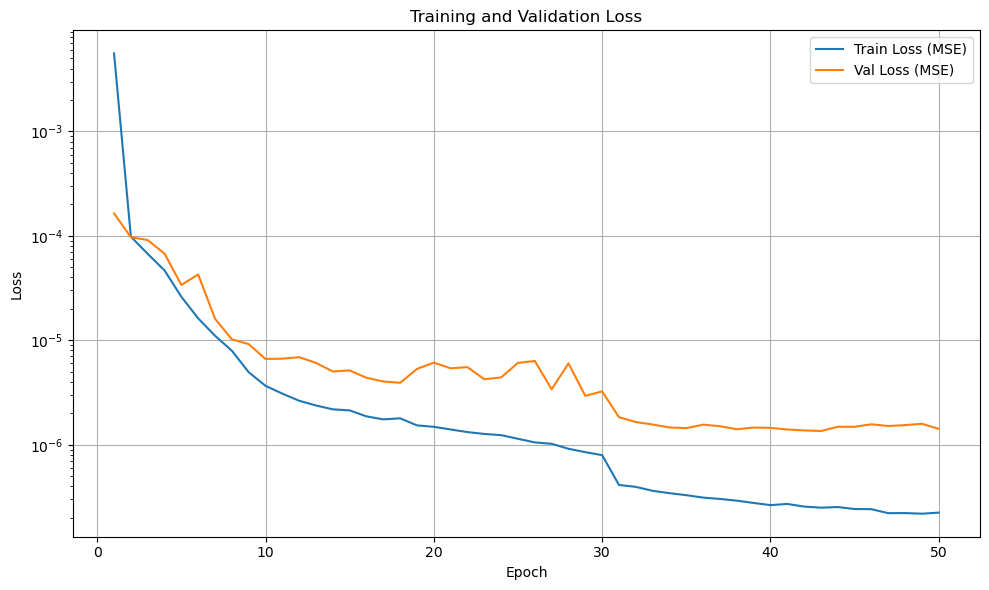

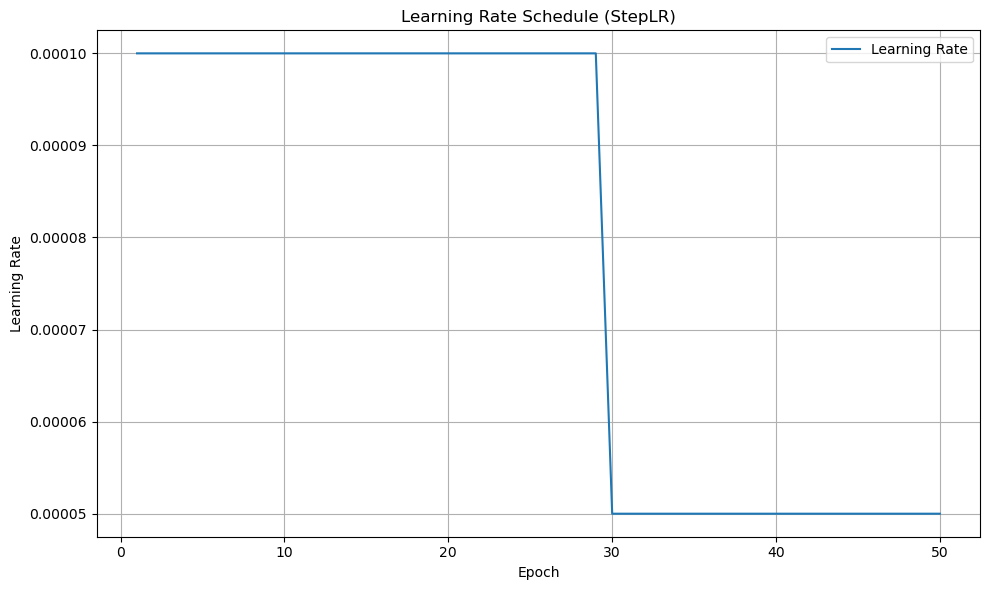

In [7]:
model, history, used_device = pipeline.train(
    epochs=epochs,
    out_dir=out_dir,
    preload_train_to_device=preload_training_data,
    early_stopping_min_delta=1e-6,
    early_stopping_patience=10,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,

    # --- profiler options ---
    # enable_torch_profiler=True,
    # profiler_wait_steps=5,
    # profiler_warmup_steps=3,
    # profiler_active_steps=10,
    # profiler_repeat=2,
    # profiler_row_limit=50,
)
print(f"Finished training using device: {used_device}")

In [9]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:01,  1.86s/profile, mae_avg=9.926000e+02]

Saved forecast plot to: ..\outputs\ml_results\training_playground\N501\Batch0003_k12_minmax\rolling_forecast_results_drum_profile_02004.png


Forecast profiles: 2profile [00:03,  1.87s/profile, mae_avg=7.149559e+02]

Saved forecast plot to: ..\outputs\ml_results\training_playground\N501\Batch0003_k12_minmax\rolling_forecast_results_drum_profile_02006.png


Forecast profiles: 3profile [00:05,  1.82s/profile, mae_avg=6.502514e+02]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\N501\Batch0003_k12_minmax\rolling_forecast_results_drum_profile_02025.png


Forecast profiles: 5profile [00:09,  1.81s/profile, mae_avg=8.088767e+02]

Saved forecast plot to: ..\outputs\ml_results\training_playground\N501\Batch0003_k12_minmax\rolling_forecast_results_drum_profile_02028.png


Forecast profiles: 150profile [00:48,  3.11profile/s, mae_avg=6.654952e+02]


Testing timing summary: total_fetch: 0.0001s -  total_test: 39.7624s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.2651s -  save_time: 0.0674s

Clearing cuda:0...


In [ ]:
save_forecast_profiles_pdf(
    forecast_h5_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.h5"),
    output_pdf_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.pdf"),
)